# 순환 신경망(RNN)

지금까지 살펴본 신경망은 **피드포워드(feed forward)(앞먹임)** 라는 유형의 신경망   
피드포워드란 흐름이 단방향인 신경망   
다시 말해, 입력 신호가 다음 층(중간층)으로 전달되고, 그 신호를 받은 층은 그다음 층으로 전달하고, 다시 다음 층으로... 식으로 한 방향으로만 신호가 전달됨   

피드포워드 신경망은 구성이 단순하여 구조를 이해하기 쉽고, 그래서 많은 문제에 응용할 수 있음   
그러나 커다란 단점이 바로 시계열 데이터를 잘 다루지 못한다는 것   
더 정확하게 말하면, 단순한 피드포워드 신경망에서는 시계열 데이터의 성질(패턴)을 충분히 학습할 수 없음   
그래서 **순환 신경망(Recurrent Neural Network)(RNN)** 이 등장   

이번 장에서는 피드포워드 신경망의 문제점을 지적하고, RNN이 그 문제를 훌륭하게 해결할 수 있음을 설명   
또한 RNN의 구조를 차분히 시간을 들여 설명하면서, 파이썬으로 구현도 해볼 것

## 확률과 언어 모델

이번 절에서는 RNN 이야기를 시작하기 위한 준비 과정으로, 먼저 앞 장의 word2vec을 복습   
그런 다음 자연어에 관한 현상을 '확률'을 사용해 기술하고, 마지막에는 언어를 확률로 다루는 '언어 모델'에 대해 설명

### word2vec을 확률 관점에서 바라보다

그럼 word2vec의 CBOW 모델부터 복습   
여기에서는 w1, w2, …, wT라는 단어열로 표현되는 말뭉치를 생각해볼 것   
그리고 t번째 단어를 '타깃'으로, 그 전후 단어(t-1번째와 t+1번째)를 '맥락'으로 취급

> 이 책에서 타깃은 '중앙 단어'를, 맥락은 타깃의 '주변 단어'를 가리킴   

이때 CBOW 모델은 아래 그림처럼 맥락 wt-1과 wt+1로부터 타깃 wt를 추측하는 일을 수행   
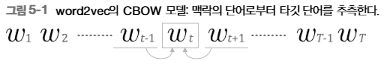   

그럼 wt-1과 wt+1이 주어졌을 때 타깃이 wt가 될 확률을 수식으로 나타내보면   
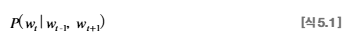   
- CBOW 모델은 이 식의 사후 확률을 모델링함
- 이 사후 확률은 'wt-1과 wt+1이 주어졌을 때 wt가 일어날 확률'을 뜻함
- 이것이 윈도우 크기가 1일 때의 CBOW 모델   

그런데 지금까지는 맥락을 항상 좌우 대칭으로 생각해왔음   
이번에는 맥락을 왼쪽 윈도우만으로 한정해봄   
예컨대 아래 그림과 같은 경우를 생각해보면   
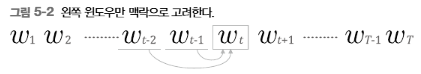   
- 그림처럼 왼쪽 두 단어만을 맥락으로 생각
- 그러면 CBOW 모델이 출력할 확률은 아래 식처럼 됨   
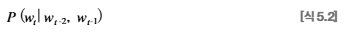   

> word2vec에서 맥락의 윈도우 크기는 하이퍼파라미터   
> 임의의 값으로 설정할 수 있다는 뜻   
> 이번 예에서는 윈도우 크기를 '왼쪽 2 단어, 오른쪽 0 단어'라는 좌우 비대칭으로 설정   
> 이렇게 설정한 이유는 나중에 설명하는 '언어 모델'에서 이야기함   

위 식의 표기를 사용하면, CBOW 모델이 다루는 손실 함수를 아래 식처럼 쓸 수 있음   
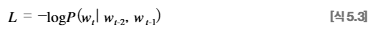   
- 이 식은 교차 엔트로피 오차에 의해 유도한 결과
- CBOW 모델의 학습으로 수행하는 일은 이 식의 손실 함수(정확히는 말뭉치 전체의 손실 함수의 총합)를 최소화하는 가중치 매개변수를 찾는 것
- 이러한 가중치 매개변수가 발견되면 CBOW 모델은 맥락으로부터 타깃을 더 정확하게 추측할 수 있게 됨   

이처럼 CBOW 모델을 학습시키는 본래 목적은 맥락으로부터 타깃을 정확하게 추측하는 것   
이 목적을 위해 학습을 진행하면, (그 부산물로) 단어의 의미가 인코딩된 '단어의 분산 표현'을 얻을 수 있음   

그럼 CBOW 모델의 본래 목적인 '맥락으로부터 타깃을 추측하는 것'은 어디에 이용할 수 있을지   
위에 식의 확률 P(wt|wt-2, wt-1)은 실용적인 쓰임이 있는지   
여기서 '언어 모델'이 등장

### 언어 모델

**언어 모델(Language Model)** 은 단어 나열에 확률을 부여함   
특정한 단어의 시퀀스에 대해서, 그 시퀀스가 일어날 가능성이 어느 정도인지(얼마나 자연스러운 단어 순서인지)를 확률로 평가하는 것   
예컨대 "you say goodbye"라는 단어 시퀀스에는 높은 확률(예: 0.092)을 출력하고, "you say good die"에는 낮은 확률(예: 0.0000000000032)을 출력하는 것이 일종의 언어 모델   

이 언어 모델은 다양하게 응용할 수 있음   
기계 번역과 음성 인식이 대표적인 예   
예를 들어 음성 인식 시스템의 경우, 사람의 음성으로부터 몇 개의 문장을 후보로 생성할 것   
그런 다음 언어 모델을 사용하여 후보 문장이 '문장으로써 자연스러운지'를 기준으로 순서를 매길 수 있음   

또한 언어 모델은 새로운 문장을 생성하는 용도로도 이용할 수 있음   
왜냐하면 언어 모델은 단어 순서의 자연스러움을 확률적으로 평가할 수 있으므로, 그 확률분포에 따라 다음으로 적합한 단어를 '자아낼'(샘플링) 수 있기 때문   

그러면 언어 모델을 수식으로 설명   
w1, ..., wm이라는 m개 단어로 된 문장을 생각해보면   
이때 단어가 w1, ..., wm이라는 순서로 출현할 확률을 P(w1, …, wm)으로 나타냄   
이 확률은 여러 사건이 동시에 일어날 확률이므로 동시 확률이라고 함   

이 동시 확률 P(w1, ..., wm)은 사후 확률을 사용하여 다음과 같이 분해하여 쓸 수 있음   
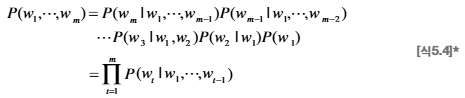   
- 식의 기호는 모든 원소를 곱하는 '총곱'을 뜻함(총합을 뜻하는 ∑(시그마)와 구분)
- 식에서 알 수 있듯, 동시 확률은 사후 확률의 총곱으로 나타낼 수 있음
- 식의 결과는 확률의 곱셈정리로부터 유도할 수 있음
- 확률의 곱셈정리는 다음 식으로 표현됨   
   
- 식의 곱셈정리는 확률론에서 가장 중요한 정리
- 이 정리가 의미하는 바는 'A와 B가 모두 일어날 확률 P(A, B)'는 'B가 일어날 확률 P(B)'와 'B가 일어난 후 A가 일어날 확률 P(A|B)'를 곱한 값과 같다는 것   

> 확률 P(A, B)를 P(A, B) = P(B|A)P(A)처럼 분해할 수도 있음   
> 즉, A와 B 중 어느 것을 사후 확률의 조건으로 할지에 따라 P(A, B) = P(B|A)P(A) 와 P(A, B) = P(A|B)P(B)의 2가지 표시 방법이 존재   

이 곱셈정리를 사용하면 m개 단어의 동시 확률 P(w1, ..., wm)을 사후 확률로 나타낼 수 있음   
이때 수행하는 식 변형을 알기 쉽게 나타내면 다음과 같음   
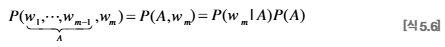   
- 여기에서는 w1, ..., wm-1을 하나로 모아 기호 A로 나타냄
- 그러면 곱셈정리를 수행하여 아래 식이 유도됨
- 이번에도 A(w1, ..., wm-1)에 대해서 다시 같은 식 변형을 수행   
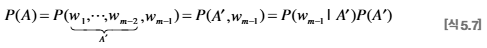   
- 이처럼 단어 시퀀스를 하나씩 줄여가면서 매번 사후 확률로 분해해 감
- 그리고 같은 과정을 반복하여 최종 식을 이끌 수 있음   

최종 식에서 알 수 있듯이 목적으로 하는 동시 확률 P(w1, ..., wm)은 사후 확률의 총곱인 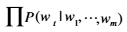으로 대표될 수 있음   
여기에서 주목할 것은 이 사후 확률은 타깃 단어보다 왼쪽에 있는 모든 단어를 맥락(조건)으로 했을 때의 확률이라는 것   
그림으로 보면   
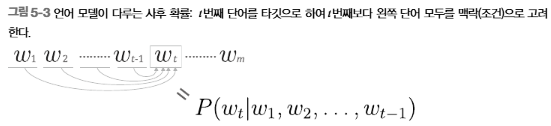   

지금까지의 이야기를 정리하면, 목표는 P(wt|w1, ..., wt-1)이라는 확률을 얻는 것   
이 확률을 계산할 수 있다면 언어 모델의 동시 확률 P(w1, ..., wm)을 구할 수 있음   

> P(wt|w1, ..., wt-1)을 나타내는 모델은 **조건부 언어 모델(Conditional Language Model)** 이라고 함   
> 한편, P(wt|w1, …, wt-1)을 나타내는 모델을 가리켜, 그것을 '언어 모델'이라 하는 경우도 많이 볼 수 있음

### CBOW 모델을 언어 모델로?

그렇다면 word2vec의 CBOW 모델을 (억지로) 언어 모델에 적용하려면 어떻게 하는지   
이는 맥락의 크기를 특정 값으로 한정하여 근사적으로 나타낼 수 있음   
수식으로는 다음과 같음   
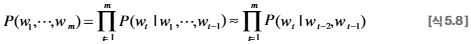   
- 여기에서는 맥락을 왼쪽 2개의 단어로 한정
- 그러면 CBOW 모델에 따라(CBOW 모델의 사후 확률에 따라) 근사적으로 나타낼 수 있음   

> 머신러닝이나 통계학에서는 **마르코프 연쇄(Markov Chain)** 또는 **마르코프 모델(Markov Model)** 이라는 말을 자주 듣을 수 있음   
> 마르코프 연쇄란 미래의 상태가 현재 상태에만 의존해 결정되는 것   
> 또한 이 사상의 확률이 '그 직전' N개의 사건에만 의존할 때, 이를 'N층 마르코프 연쇄'라고 함   
> 이번 예는 직전 2개의 단어에만 의존해 다음 단어가 정해지는 모델이므로 '2층 마르코프 연쇄'라고 부를 수 있음   

위 식에서는 맥락으로 2개의 단어를 이용하는 예를 나타냈지만, 이 맥락의 크기는 임의 길이로 설정할 수 있음(예컨대 5나 10 등)   
그러나 임의 길이로 설정할 수 있다고 해도, 결국 특정 길이로 '고정'됨   
예를 들어 왼쪽 10개의 단어를 맥락으로 CBOW 모델을 만든다고 하면, 그 맥락보다 더 왼쪽에 있는 단어의 정보는 무시됨   
이것이 문제가 될 때가 있는데, 아래 그림이 그 예시   
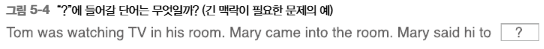   
- 그림의 문제에서 "Tom이 방에서 TV를 보고 있었고, Mary가 그 방에 들어왔다"고 함
- 이 문맥(맥락)을 고려하면 "Mary가 Tom(혹은 he)에게 인사를 건넸다"가 정답
- 이 문제에서 정답을 구하려면 예문의 '?'로부터 18번째나 앞에 나오는 "Tom"을 기억해야 함
- 만약 CBOW 모델의 맥락이 10개까지였다면 이 문제에 제대로 답할 수 없을 것   

그럼 CBOW 모델의 맥락 크기를 20이나 30까지 키우면 문제가 해결되는지   
물론 CBOW 모델의 맥락 크기는 얼마든지 키울 수 있음   
그러나 CBOW 모델에서는 맥락 안의 단어 순서가 무시된다는 한계가 있음   

> CBOW란 continuous bag-of-words의 약어   
> bag-of-words란 '가방 안의 단어'를 뜻하는데, 여기에는 가방 속의 단어 '순서'는 무시된다는 뜻도 내포함('순서'대신 '분포'를 이용함)   

맥락의 단어 순서가 무시되는 문제의 구체적인 예를 하나 보면   
예컨대 맥락으로 2개의 단어를 다루는 경우, CBOW 모델에서는 이 2개의 단어 벡터의 '합'이 은닉층에 옴(아래 그림의 왼쪽처럼)   
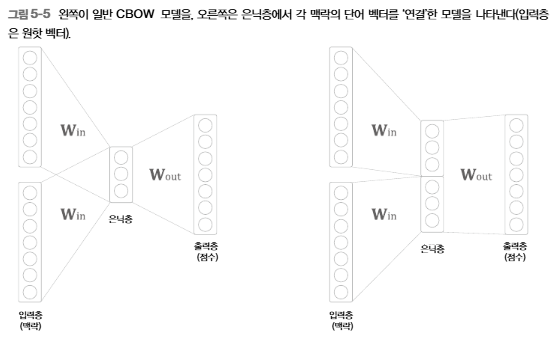   
- 그림의 왼쪽 그림과 같이 CBOW 모델의 은닉층에서는 단어 벡터들이 더해지므로 맥락의 단어 순서는 무시됨
- 예컨대 (you, say)와 (say, you)라는 맥락을 똑같이 취급함
- 이상적으로는 맥락의 단어 순서도 고려한 모델이 바람직
- 이를 위해 그림의 오른쪽처럼 맥락의 단어 벡터를 은닉층에서 **연결(concatenate)** 하는 방식을 생각할 수 있음
- 실제, 신경 확률론적 언어 모델(Neural Probabilistic Language Model)에서 제안한 모델은 이 방식을 취함
- 그러나 연결하는 방식을 취하면 맥락의 크기에 비례해 가중치 매개변수도 늘어나게 됨 - 좋지 않은 현상   

이 문제를 해결하는 것이 순환 신경망(RNN)   
RNN은 맥락이 아무리 길더라도 그 맥락의 정보를 기억하는 메커니즘을 갖추고 있음   
그래서 RNN을 사용하면 아무리 긴 시계열 데이터에라도 대응할 수 있음   

> word2vec은 단어의 분산 표현을 얻을 목적으로 고안된 기법   
> 따라서 이를 언어 모델로 사용하는 경우는 (보통은) 잘 없음   
> 여기에서는 RNN의 특징을 끌어내기 위해 word2vec의 CBOW 모델을 억지로 언어 모델에 적용해본 것   
> 그리고 word2vec은 2013년에, RNN을 이용한 언어 모델은 2010년에 토마스 미콜로프가 이끄는 연구팀에 의해 각각 제안되었음   
> 이들이 설명한 연구 배경에 따르면, RNN을 이용한 언어 모델에서도 단어의 분산 표현을 얻을 수 있지만,   
> 어휘 수 증가에 따른 대응이나 단어의 분산 표현의 '질' 개선을 위해 word2vec을 제안했다고 함

## RNN이란

RNN(Recurrent Neural Network)의 'Recurrent'는 라틴어에서 온 말로, '몇 번이나 반복해서 일어나는 일'을 뜻함   
우리말로는 '재발한다', '주기적으로 일어난다', '순환한다' 등으로 번역됨   
그래서 RNN을 직역하면 '순화하는 신경망'이 되는 것   
이번 절에서는 이 '순환한다'는 말의 의미를 살펴봄   

> Recurrent Neural Network는 우리말로 '순환 신경망'으로 번역함   
> 한편, Recursive Neural Network(재귀 신경망)라는 신경망도 있음   
> 이는 주로 트리 구조의 데이터를 처리하기 위한 신경망으로, 순환 신경망과는 다른 것

### 순환하는 신경망

'순환한다'는 '반복해서 되돌아감'을 의미   
어느 한 지점에서 시작한 것이, 시간을 지나 다시 원래 장소로 돌아오는 것, 그리고 이 과정을 반복하는 것이 바로 '순환'   
여기서 하나 주목할 사실은, 순환하기 위해서는 '닫힌 경로'가 필요하다는 것   

'닫힌 경로' 혹은 '순환하는 경로'가 존재해야 데이터가 같은 장소를 반복해 왕래할 수 있음   
그리고 데이터가 순환하면서 정보가 끊임없이 갱신되게 됨   

> 비유하자면, 혈액은 우리 체내를 순환함   
> 지금 흐르는 혈액은 어제부터 계속해서 흐르던 혈액   
> 나아가 1주일 전부터, 1개월 전부터, 1년 전부터, 그리고 생명을 얻은 그 순간부터 계속해 흘러왔음   
> 그리고 체내를 순환하며 과거로부터 현재로 끊임없이 '갱신'됨   

RNN의 특징은 순환하는 경로(닫힌 경로)가 있다는 것   
이 순환 경로를 따라 데이터는 끊임없이 순환할 수 있음   
그리고 데이터가 순환되기 때문에 과거의 정보를 기억하는 동시에 최신 데이터로 갱신될 수 있는 것   

그럼 RNN을 구체적으로 살펴보면   
여기에서는 RNN에 이용되는 계층을 'RNN 계층'이라고 부름   
RNN 계층은 아래 그림처럼 그릴 수 있음   
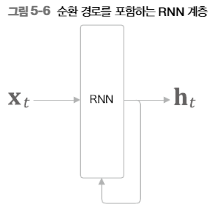   
- 그림처럼 RNN 계층은 순환하는 경로를 포함
- 이 순환 경로를 따라 데이터를 계층 안에서 순환시킬 수 있음
- 또한 그림에서는 xt를 입력받는데, t는 시각을 뜻함
- 이는 시계열 데이터 (x0, x1, ..., xt, ...)가 RNN 계층에 입력됨을 표현한 것
- 그리고 그 입력에 대응하여 (h0, h1, ..., ht, ...)가 출력됨
- 또한, 각 시각에 입력되는 xt는 벡터라고 가정함
- 문장(단어 순서)을 다루는 경우를 예로 든다면 각 단어의 분산 표현(단어 벡터)이 xt가 되며, 이 분산 표현이 순서대로 하나씩 RNN 계층에 입력되는 것   

> 그림을 잘 보면 출력이 2개로 분기하고 있음을 알 수 있음   
> 여기서 말하는 '분기'란 같은 것이 복제되어 분기함을 의미   
> 그리고 이렇게 분기된 출력 중 하나가 자기 자신에 입력됨(즉, 순환함)   

이어서 그림의 순환 구조를 자세히 살펴볼 차례이지만, 그전에 RNN 계층을 그리는 방식을 다음과 같이 변경하고자 함   
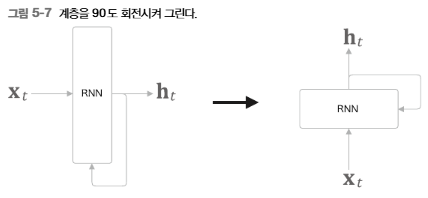   
- 그림에서 보듯, 지금까지는 계층을 그릴 때 데이터가 왼쪽에서 오른쪽으로 흐르는 형태로 그렸음
- 그러나 지금부터는 지면 관계상 아래에서 위로 흐르도록 그림(곧이어 순환 구조를 펼쳐볼 텐데, 이때 계층을 양옆으로 펼치기 위해서)

### 순환 구조 펼치기

그럼, RNN 계층의 순환 구조에 대해 자세하게 살펴봄   
RNN의 순환 구조는 지금까지의 신경망에는 존재하지 않던 구조   
그러나 이 순환 구조를 펼치면 친숙한 신경망으로 '변신'시킬 수 있음   
실제로 한번 펼쳐보면   
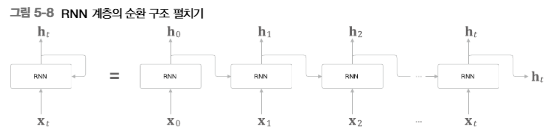   
- 그림에서 보듯, RNN 계층의 순환 구조를 펼침으로써 오른쪽으로 성장하는 긴 신경망으로 변신시킬 수 있음
- 지금까지 본 피드포워드 신경망과 같은 구조(피드포워드에서는 데이터가 한 방향으로만 흐름)
- 다만, 그림에 등장하는 다수의 RNN 계층 모두가 실제로는 '같은 계층'인 것이 지금까지의 신경망과는 다름   

> 시계열 데이터는 시간 방향으로 데이터가 나열됨   
> 따라서 시계열 데이터의 인덱스를 가리킬 때는 '시각'이라는 용어를 사용함(예컨대 시각 t의 입력 데이터 xt 등)   
> 자연어의 경우에도 't번째 단어'나 't번째 RNN 계층'이라는 표현도 사용하지만, '시각 t의 단어'나 '시각 t의 RNN 계층'처럼 표현하기도 함   

그림을 보면 알 수 있듯, 각 시각의 RNN 계층은 그 계층으로의 입력과 1개 전의 RNN 계층으로부터의 출력을 받음   
그리고 이 두 정보를 바탕으로 현 시각의 출력을 계산함   
이때 수행하는 계산의 수식은 다음과 같음   
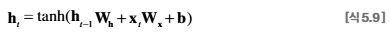   
- 우선 식에 쓰인 기호들을 설명하면
    - RNN에서는 가중치가 2개 있는데 하나는 입력 x를 출력 h로 변환하기 위한 가중치 Wx이고, 다른 하나는 1개의 RNN 출력을 다음 시각의 출력으로 변환하기 위한 가중치 Wh
    - 또한 편향 b도 있음
    - 참고로 ht-1과 xt는 행 벡터
- 식에서는 행렬 곱을 계산하고, 그 합을 tanh 함수(쌍곡탄젠트(hyperbolic tangent) 함수)를 이용해 변환함
- 그 결과가 시각 t의 출력 ht가 됨
- 이 ht는 다른 계층을 향해 위쪽으로 출력되는 동시에, 다음 시각의 RNN 계층(자기 자신)을 향해 오른쪽으로도 출력됨